In [ ]:
### pyFIA Tools - Jupyter Notebook Demo ###
# -*- coding: utf-8 -*-
# Credits
"""
Created on Thu Apr 17 13:07:10 2025

@author: xinyuan.wei
"""

In [ ]:
###----------------------------------------------------------------------------
# Data Prep
###----------------------------------------------------------------------------

In [1]:
# Import necessary packages (install into your environemnt beforehand)
import pandas as pd
import geopandas as gpd
import _pyFIA_Tools as tl

In [10]:
# State and FIPS - Georgia in this example
State = 'GA'
FIPS = '13'

In [3]:
# Load the FIA Tree, Condition, Plot, County, Pop_stratum, Pop_Stratum_Assgn data
FIA_Data = {
    'tree_data': pd.read_csv(f'{State}_CSV/{State}_TREE.csv', low_memory=False),
    'cond_data': pd.read_csv(f'{State}_CSV/{State}_COND.csv', low_memory=False),
    'plot_data': pd.read_csv(f'{State}_CSV/{State}_PLOT.csv', low_memory=False),
    'coty_data': pd.read_csv(f'{State}_CSV/{State}_COUNTY.csv', low_memory=False),
    'tgrm_data': pd.read_csv(f'{State}_CSV/{State}_TREE_GRM_ESTN.csv', low_memory=False),
    'pops_data': pd.read_csv(f'{State}_CSV/{State}_POP_STRATUM.csv', low_memory=False),
    'popp_data': pd.read_csv(f'{State}_CSV/{State}_POP_PLOT_STRATUM_ASSGN.csv', low_memory=False)
}

In [4]:
# Load the US basemap (shapefile)
basemap = gpd.read_file('_US_Boundary/us_boundary.shp')

In [5]:
###----------------------------------------------------------------------------
# PyFIA Tools
###----------------------------------------------------------------------------

In [6]:
# Recode Plot ID 'PLOT' to COUNTYCD + PLOT 
savefolder = f'_Results/{State}_CSV'
tl.recode_plot(FIA_Data=FIA_Data, savefolder=savefolder, state=State)

{'tree_data':                        CN            PLT_CN   PREV_TRE_CN  INVYR  STATECD  \
 0         158870927010854   158712463010854           NaN   1972       13   
 1         158870928010854   158712463010854           NaN   1972       13   
 2         158870929010854   158712463010854           NaN   1972       13   
 3         158870930010854   158712463010854           NaN   1972       13   
 4         158870931010854   158712463010854           NaN   1972       13   
 ...                   ...               ...           ...    ...      ...   
 1847609  1738010623290487  1279212447290487  7.203384e+14   2023       13   
 1847610  1738010624290487  1279212447290487  7.203384e+14   2023       13   
 1847611  1738010625290487  1279212447290487  7.203384e+14   2023       13   
 1847612  1738010626290487  1279212447290487  7.203384e+14   2023       13   
 1847613  1738010627290487  1279212447290487           NaN   2023       13   
 
          UNITCD  COUNTYCD  PLOT_OLD     PLOT  SU

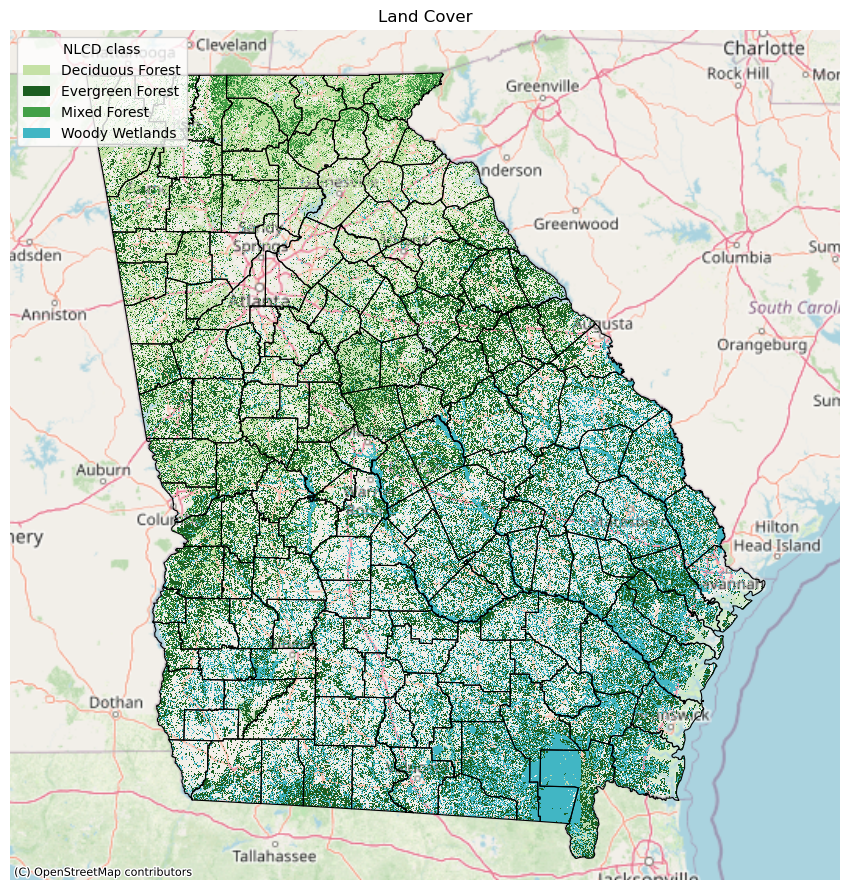

In [7]:
# Extract the land cover (NLCD) data for a given state
NLCD_file = '_NLCD/NLCD_2024.tif'
savefile  = f'_NLCD/NLCD_{State}.tif'
tl.state_NLCD(NLCD_file=NLCD_file,
              basemap=basemap,
              savefile=savefile,
              FIPS=FIPS)

In [11]:
# Merge data tables for further analysis
# Switches to Maine, from previous notebook
file1 = '_Results/ME_Plot_Biomass_Climate.csv'
file2 = '_Results/ME_Plot_Composition.csv'
file3 = '_Results/ME_Plot_Structure_Indices.csv'
savefile2 = '_Results/ME_Merged.csv'
savefile3 = '_Results/ME_Merged.csv'
# Merge two files
merged = tl.data_merge(file1, file2, savefile=savefile2)
# Merge many files
merged = tl.data_merge([file1, file2, file3], savefile=savefile3)

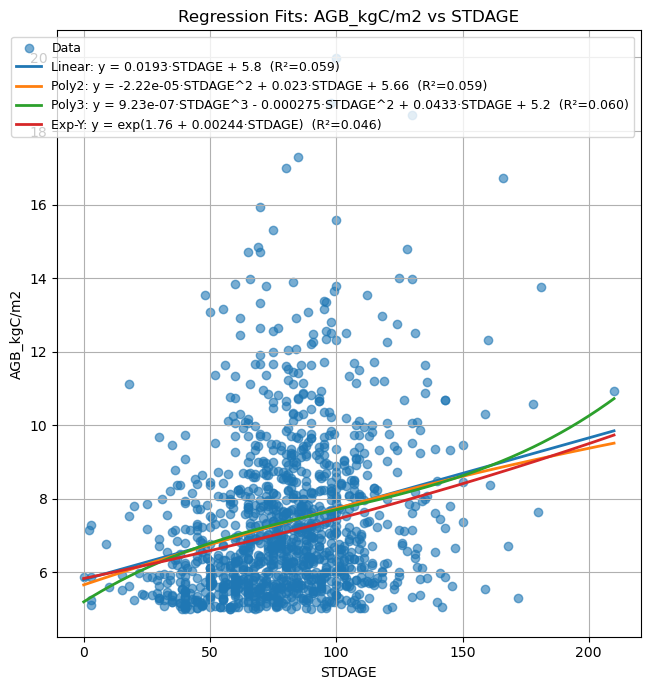

Linear => Linear: y = 0.0193·STDAGE + 5.8  (R²=0.059)
Poly2 => Poly2: y = -2.22e-05·STDAGE^2 + 0.023·STDAGE + 5.66  (R²=0.059)
Poly3 => Poly3: y = 9.23e-07·STDAGE^3 - 0.000275·STDAGE^2 + 0.0433·STDAGE + 5.2  (R²=0.060)
Exp-Y => Exp-Y: y = exp(1.76 + 0.00244·STDAGE)  (R²=0.046)


In [9]:
# Analyze the relationship between variables
data     = '_Results/ME_Plot_Biomass_Climate.csv'
filters  = {'STDAGE': (0, 250), 'AGB_kgC/m2': (5, None)}
ind_var  = 'STDAGE'
dep_var  = 'AGB_kgC/m2'
regression = tl.regre(data=data,
                      ind_var=ind_var,
                      dep_var=dep_var,
                      filters=filters,
                      max_poly=3)
for k, v in regression.items():
    print(k, '=>', v)